# Breakout/Bust Model: Empirical Valuation Adjustments

The breakout/bust classifier has useful **ranking signal** (lift > 1x) but uninformative probability estimates. This analysis derives **empirical dollar adjustments** by measuring how much more (or less) the model's flagged candidates are actually worth relative to their ADP peers.

**Approach:**
1. For each holdout season, train the model and rank players by P(breakout) / P(bust)
2. Join with actual ZAR auction values and ADP data
3. For each ADP tier, compute the "fair value" — the average actual value of players drafted in that range
4. The **surplus** for each player is `actual_value - fair_value_for_ADP_tier`
5. Compare average surplus for model-flagged candidates vs the rest

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier

from fantasy_baseball_manager.cli.factory import DbLabelSource
from fantasy_baseball_manager.db.connection import create_connection
from fantasy_baseball_manager.db.pool import SingleConnectionProvider
from fantasy_baseball_manager.features import SqliteDatasetAssembler
from fantasy_baseball_manager.models.breakout_bust.model import (
    _DEFAULT_FEATURE_COLUMNS,
    _FEATURE_SET_BUILDERS,
    LABEL_TO_INT,
    _join_labels_with_features,
)
from fantasy_baseball_manager.models.gbm_training import extract_features

warnings.filterwarnings("ignore")

conn = create_connection(Path("../data/fbm.db"))
provider = SingleConnectionProvider(conn)
assembler = SqliteDatasetAssembler(provider, statcast_path=Path("../data/statcast.db"))
label_source = DbLabelSource(conn)

SEASONS = [2019, 2021, 2022, 2023, 2024]
print(f"Using seasons: {SEASONS}")

Using seasons: [2019, 2021, 2022, 2023, 2024]


## 1. Build Model Predictions + Actual Values

For each holdout season, train the classifier on prior seasons and produce P(breakout)/P(bust) rankings. Then join with actual ZAR valuations.

In [2]:
def build_joined_rows(seasons, player_type):
    labels = []
    for s in seasons:
        labels.extend(ls for ls in label_source.get_labels(s) if ls.player_type == player_type)
    builder = _FEATURE_SET_BUILDERS[player_type]
    feature_set = builder(seasons)
    handle = assembler.get_or_materialize(feature_set)
    rows = assembler.read(handle)
    return _join_labels_with_features(labels, rows)


def train_and_predict(train_seasons, holdout_season, player_type):
    all_seasons = sorted(set(train_seasons) | {holdout_season})
    joined = build_joined_rows(all_seasons, player_type)
    if not joined:
        return None
    feature_columns = _DEFAULT_FEATURE_COLUMNS[player_type]
    train_rows = [r for r in joined if r["season"] != holdout_season]
    holdout_rows = [r for r in joined if r["season"] == holdout_season]
    if not train_rows or not holdout_rows:
        return None

    X_train = extract_features(train_rows, feature_columns)
    y_train = [LABEL_TO_INT[r["label"]] for r in train_rows]
    clf = HistGradientBoostingClassifier(max_iter=200, max_depth=5, learning_rate=0.1, min_samples_leaf=10)
    clf.fit(X_train, y_train)

    X_holdout = extract_features(holdout_rows, feature_columns)
    proba = clf.predict_proba(X_holdout)
    class_to_idx = {c: i for i, c in enumerate(clf.classes_)}
    breakout_idx = class_to_idx.get(1, 1)
    bust_idx = class_to_idx.get(2, 2)

    return [
        {
            "player_id": row["player_id"],
            "season": holdout_season,
            "player_type": player_type,
            "adp_pick": row["adp_pick"],
            "label": row["label"].value,
            "p_breakout": float(proba[i, breakout_idx]),
            "p_bust": float(proba[i, bust_idx]),
        }
        for i, row in enumerate(holdout_rows)
    ]


# Collect predictions for all holdout seasons
all_preds = []
holdout_seasons = [2021, 2022, 2023, 2024]

for holdout in holdout_seasons:
    train_seasons = [s for s in SEASONS if s < holdout]
    if not train_seasons:
        continue
    for ptype in ("batter", "pitcher"):
        preds = train_and_predict(train_seasons, holdout, ptype)
        if preds:
            all_preds.extend(preds)

pred_df = pd.DataFrame(all_preds)
print(f"Total predictions: {len(pred_df)}")
print(pred_df.groupby(["season", "player_type"]).size().unstack(fill_value=0))

Total predictions: 1126
player_type  batter  pitcher
season                      
2021            208       67
2022            162      117
2023            165      118
2024            176      113


In [3]:
# Join with actual ZAR valuations
actual_vals = pd.read_sql(
    """
    SELECT player_id, season, player_type, value AS actual_value, rank AS actual_rank
    FROM valuation
    WHERE system = 'zar' AND version = '1.0'
      AND projection_system = 'actual'
      AND season IN (2021, 2022, 2023, 2024)
""",
    conn,
)

print(f"Actual valuations: {len(actual_vals)}")

df = pred_df.merge(actual_vals, on=["player_id", "season", "player_type"], how="inner")
print(f"Joined rows: {len(df)}")
print("\nSample:")
df.sort_values("p_breakout", ascending=False).head(10)

Actual valuations: 6324
Joined rows: 1126

Sample:


,player_id,season,player_type,adp_pick,label,p_breakout,p_bust,actual_value,actual_rank
476,9815,2022,pitcher,129.0,bust,0.999998,1.656986e-07,0.00,791
536,22158,2022,pitcher,97.0,breakout,0.999998,8.321663e-08,16.06,77
473,9305,2022,pitcher,181.0,bust,0.999997,2.870849e-06,0.00,850
218,7704,2021,pitcher,175.0,breakout,0.999996,3.318193e-06,1.71,103
226,9305,2021,pitcher,155.0,breakout,0.999996,3.666632e-06,3.49,95
268,23004,2021,pitcher,176.0,breakout,0.999990,8.521024e-06,8.76,73
213,3486,2021,pitcher,141.0,breakout,0.999990,9.733371e-06,4.93,88
504,15999,2022,pitcher,174.0,bust,0.999990,9.864861e-06,0.00,1017
221,8423,2021,pitcher,60.0,bust,0.999974,3.527700e-06,0.00,1232
264,22158,2021,pitcher,149.0,breakout,0.999974,2.590426e-05,22.44,39


## 2. Compute ADP-Tier Fair Values

Group players into ADP tiers (draft rounds in a 12-team league: picks 1-12, 13-24, ...). Within each tier, the **fair value** is the average actual ZAR value of all players drafted in that range. A player's **surplus** is how much they beat or missed that tier's fair value.

In [4]:
# Define ADP tiers as draft rounds (12-team league)
def adp_tier(pick):
    if pick <= 12:
        return "Rd 1 (1-12)"
    elif pick <= 36:
        return "Rd 2-3 (13-36)"
    elif pick <= 72:
        return "Rd 4-6 (37-72)"
    elif pick <= 120:
        return "Rd 7-10 (73-120)"
    elif pick <= 180:
        return "Rd 11-15 (121-180)"
    else:
        return "Rd 16+ (181+)"


TIER_ORDER = [
    "Rd 1 (1-12)",
    "Rd 2-3 (13-36)",
    "Rd 4-6 (37-72)",
    "Rd 7-10 (73-120)",
    "Rd 11-15 (121-180)",
    "Rd 16+ (181+)",
]

df["adp_tier"] = df["adp_pick"].apply(adp_tier)

# Compute fair value per (season, player_type, adp_tier)
fair_values = (
    df.groupby(["season", "player_type", "adp_tier"])["actual_value"]
    .mean()
    .reset_index()
    .rename(columns={"actual_value": "tier_fair_value"})
)

df = df.merge(fair_values, on=["season", "player_type", "adp_tier"])
df["surplus"] = df["actual_value"] - df["tier_fair_value"]

# Show tier fair values
print("Average actual value by ADP tier (pooled across seasons):")
tier_summary = (
    df.groupby(["player_type", "adp_tier"])
    .agg(
        n=("surplus", "size"),
        avg_actual=("actual_value", "mean"),
        avg_fair=("tier_fair_value", "mean"),
    )
    .reset_index()
)
for ptype in ("batter", "pitcher"):
    print(f"\n  {ptype.upper()}")
    sub = tier_summary[tier_summary["player_type"] == ptype]
    sub = sub.set_index("adp_tier").reindex(TIER_ORDER).dropna()
    print(sub.to_string())

Average actual value by ADP tier (pooled across seasons):

  BATTER
                   player_type    n  avg_actual   avg_fair
adp_tier                                                  
Rd 1 (1-12)             batter   46   36.640870  36.640870
Rd 2-3 (13-36)          batter   76   16.078289  16.078289
Rd 4-6 (37-72)          batter   98    7.106633   7.106633
Rd 7-10 (73-120)        batter  122    6.572787   6.572787
Rd 11-15 (121-180)      batter  164    1.610488   1.610488
Rd 16+ (181+)           batter  205    1.560878   1.560878

  PITCHER
                   player_type    n  avg_actual   avg_fair
adp_tier                                                  
Rd 1 (1-12)            pitcher   10   30.173000  30.173000
Rd 2-3 (13-36)         pitcher   42   18.863571  18.863571
Rd 4-6 (37-72)         pitcher   65   15.419077  15.419077
Rd 7-10 (73-120)       pitcher   80   11.888500  11.888500
Rd 11-15 (121-180)     pitcher   96    5.768229   5.768229
Rd 16+ (181+)          pitcher  122 

## 3. Surplus by Model Tier

Rank players by P(breakout) within each (season, player_type), assign model tiers (top-10, top-20, rest), and compare average surplus. Same for P(bust).

In [5]:
def assign_model_tier(group, prob_col, ascending=False):
    """Rank within group and assign top-10, top-20, rest."""
    ranked = group.sort_values(prob_col, ascending=ascending)
    n = len(ranked)
    tiers = ["rest"] * n
    for i in range(min(20, n)):
        tiers[i] = "top-20"
    for i in range(min(10, n)):
        tiers[i] = "top-10"
    ranked = ranked.copy()
    ranked["model_tier"] = tiers
    return ranked


# Breakout tiers
breakout_dfs = []
for (season, ptype), group in df.groupby(["season", "player_type"]):
    breakout_dfs.append(assign_model_tier(group, "p_breakout"))
breakout_df = pd.concat(breakout_dfs)

# Bust tiers (rank by highest p_bust)
bust_dfs = []
for (season, ptype), group in df.groupby(["season", "player_type"]):
    bust_dfs.append(assign_model_tier(group, "p_bust"))
bust_df = pd.concat(bust_dfs)

# --- Breakout surplus by model tier ---
print("=" * 70)
print("  BREAKOUT: Average surplus by model tier (pooled across seasons)")
print("=" * 70)
for ptype in ("batter", "pitcher"):
    sub = breakout_df[breakout_df["player_type"] == ptype]
    summary = (
        sub.groupby("model_tier")
        .agg(
            n=("surplus", "size"),
            avg_surplus=("surplus", "mean"),
            median_surplus=("surplus", "median"),
            avg_actual_value=("actual_value", "mean"),
            pct_breakout=("label", lambda x: (x == "breakout").mean()),
        )
        .reindex(["top-10", "top-20", "rest"])
    )
    print(f"\n  {ptype.upper()}")
    print(summary.round(2).to_string())

# --- Bust surplus by model tier ---
print("\n" + "=" * 70)
print("  BUST: Average surplus by model tier (pooled across seasons)")
print("=" * 70)
for ptype in ("batter", "pitcher"):
    sub = bust_df[bust_df["player_type"] == ptype]
    summary = (
        sub.groupby("model_tier")
        .agg(
            n=("surplus", "size"),
            avg_surplus=("surplus", "mean"),
            median_surplus=("surplus", "median"),
            avg_actual_value=("actual_value", "mean"),
            pct_bust=("label", lambda x: (x == "bust").mean()),
        )
        .reindex(["top-10", "top-20", "rest"])
    )
    print(f"\n  {ptype.upper()}")
    print(summary.round(2).to_string())

  BREAKOUT: Average surplus by model tier (pooled across seasons)

  BATTER
              n  avg_surplus  median_surplus  avg_actual_value  pct_breakout
model_tier                                                                  
top-10       40         0.54           -1.72              2.62          0.50
top-20       40         4.42           -1.51              7.09          0.40
rest        631        -0.31           -2.46              7.29          0.13

  PITCHER
              n  avg_surplus  median_surplus  avg_actual_value  pct_breakout
model_tier                                                                  
top-10       40        -1.23           -4.14              8.66          0.35
top-20       40         1.25           -4.10             10.94          0.45
rest        335        -0.00           -3.98             10.26          0.28

  BUST: Average surplus by model tier (pooled across seasons)

  BATTER
              n  avg_surplus  median_surplus  avg_actual_value  pct_bu

## 4. Empirical Adjustments by ADP Tier

The raw surplus numbers mix players from all ADP ranges. But a breakout from round 1 is worth more in absolute dollars than a breakout from round 15. Break it down by ADP tier to see where the model adds the most value.

In [6]:
# Breakout: surplus by model tier AND ADP tier
print("BREAKOUT candidates: avg surplus by ADP tier")
print("(Positive = model-flagged players outperform their ADP peers)\n")

for ptype in ("batter", "pitcher"):
    print(f"  {ptype.upper()}")
    sub = breakout_df[breakout_df["player_type"] == ptype]
    pivot = sub.pivot_table(
        values="surplus",
        index="adp_tier",
        columns="model_tier",
        aggfunc=["mean", "size"],
    )
    # Flatten columns
    flat = pd.DataFrame()
    for tier in ["top-10", "top-20", "rest"]:
        if ("mean", tier) in pivot.columns:
            flat[f"{tier}_surplus"] = pivot[("mean", tier)].round(1)
            flat[f"{tier}_n"] = pivot[("size", tier)].fillna(0).astype(int)
    flat = flat.reindex(TIER_ORDER).dropna(how="all")
    print(flat.to_string())
    print()

print("\nBUST risks: avg surplus by ADP tier")
print("(Negative = model-flagged players underperform their ADP peers)\n")

for ptype in ("batter", "pitcher"):
    print(f"  {ptype.upper()}")
    sub = bust_df[bust_df["player_type"] == ptype]
    pivot = sub.pivot_table(
        values="surplus",
        index="adp_tier",
        columns="model_tier",
        aggfunc=["mean", "size"],
    )
    flat = pd.DataFrame()
    for tier in ["top-10", "top-20", "rest"]:
        if ("mean", tier) in pivot.columns:
            flat[f"{tier}_surplus"] = pivot[("mean", tier)].round(1)
            flat[f"{tier}_n"] = pivot[("size", tier)].fillna(0).astype(int)
    flat = flat.reindex(TIER_ORDER).dropna(how="all")
    print(flat.to_string())
    print()

BREAKOUT candidates: avg surplus by ADP tier
(Positive = model-flagged players outperform their ADP peers)

  BATTER
                    top-10_surplus  top-10_n  top-20_surplus  top-20_n  rest_surplus  rest_n
adp_tier                                                                                    
Rd 1 (1-12)                    NaN         0             NaN         0          -0.0      46
Rd 2-3 (13-36)                 NaN         0           -11.1         1           0.1      75
Rd 4-6 (37-72)                 0.8         1            -6.2         2           0.1      95
Rd 7-10 (73-120)              -5.5         3            51.3         4          -1.6     115
Rd 11-15 (121-180)            -0.7         5            -0.6         5           0.0     154
Rd 16+ (181+)                  1.3        31            -0.1        28          -0.3     146

  PITCHER
                    top-10_surplus  top-10_n  top-20_surplus  top-20_n  rest_surplus  rest_n
adp_tier                           

## 5. Season-by-Season Stability

Do the adjustments hold up across seasons, or are they driven by one outlier year?

In [7]:
# Season-by-season breakout surplus for top-20 vs rest
print("BREAKOUT top-20 surplus by season")
print("(Does the model's edge hold up year-over-year?)\n")

for ptype in ("batter", "pitcher"):
    print(f"  {ptype.upper()}")
    sub = breakout_df[breakout_df["player_type"] == ptype]
    rows = []
    for season in sorted(sub["season"].unique()):
        s = sub[sub["season"] == season]
        top20 = s[s["model_tier"].isin(["top-10", "top-20"])]
        rest = s[s["model_tier"] == "rest"]
        rows.append(
            {
                "season": season,
                "top20_n": len(top20),
                "top20_surplus": round(top20["surplus"].mean(), 1),
                "rest_n": len(rest),
                "rest_surplus": round(rest["surplus"].mean(), 1),
                "edge": round(top20["surplus"].mean() - rest["surplus"].mean(), 1),
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))
    print()

print("\nBUST top-20 surplus by season\n")

for ptype in ("batter", "pitcher"):
    print(f"  {ptype.upper()}")
    sub = bust_df[bust_df["player_type"] == ptype]
    rows = []
    for season in sorted(sub["season"].unique()):
        s = sub[sub["season"] == season]
        top20 = s[s["model_tier"].isin(["top-10", "top-20"])]
        rest = s[s["model_tier"] == "rest"]
        rows.append(
            {
                "season": season,
                "top20_n": len(top20),
                "top20_surplus": round(top20["surplus"].mean(), 1),
                "rest_n": len(rest),
                "rest_surplus": round(rest["surplus"].mean(), 1),
                "edge": round(top20["surplus"].mean() - rest["surplus"].mean(), 1),
            }
        )
    print(pd.DataFrame(rows).to_string(index=False))
    print()

BREAKOUT top-20 surplus by season
(Does the model's edge hold up year-over-year?)

  BATTER
 season  top20_n  top20_surplus  rest_n  rest_surplus  edge
   2021       20            9.1     188          -1.0  10.0
   2022       20            0.0     142          -0.0   0.0
   2023       20           -0.7     145           0.1  -0.8
   2024       20            1.5     156          -0.2   1.7

  PITCHER
 season  top20_n  top20_surplus  rest_n  rest_surplus  edge
   2021       20           -1.2      47           0.5  -1.7
   2022       20            3.5      97          -0.7   4.2
   2023       20            0.2      98          -0.0   0.2
   2024       20           -2.5      93           0.5  -3.0


BUST top-20 surplus by season

  BATTER
 season  top20_n  top20_surplus  rest_n  rest_surplus  edge
   2021       20           -3.9     188           0.4  -4.3
   2022       20            3.3     142          -0.5   3.8
   2023       20            1.3     145          -0.2   1.5
   2024       2

## 6. Visualizations

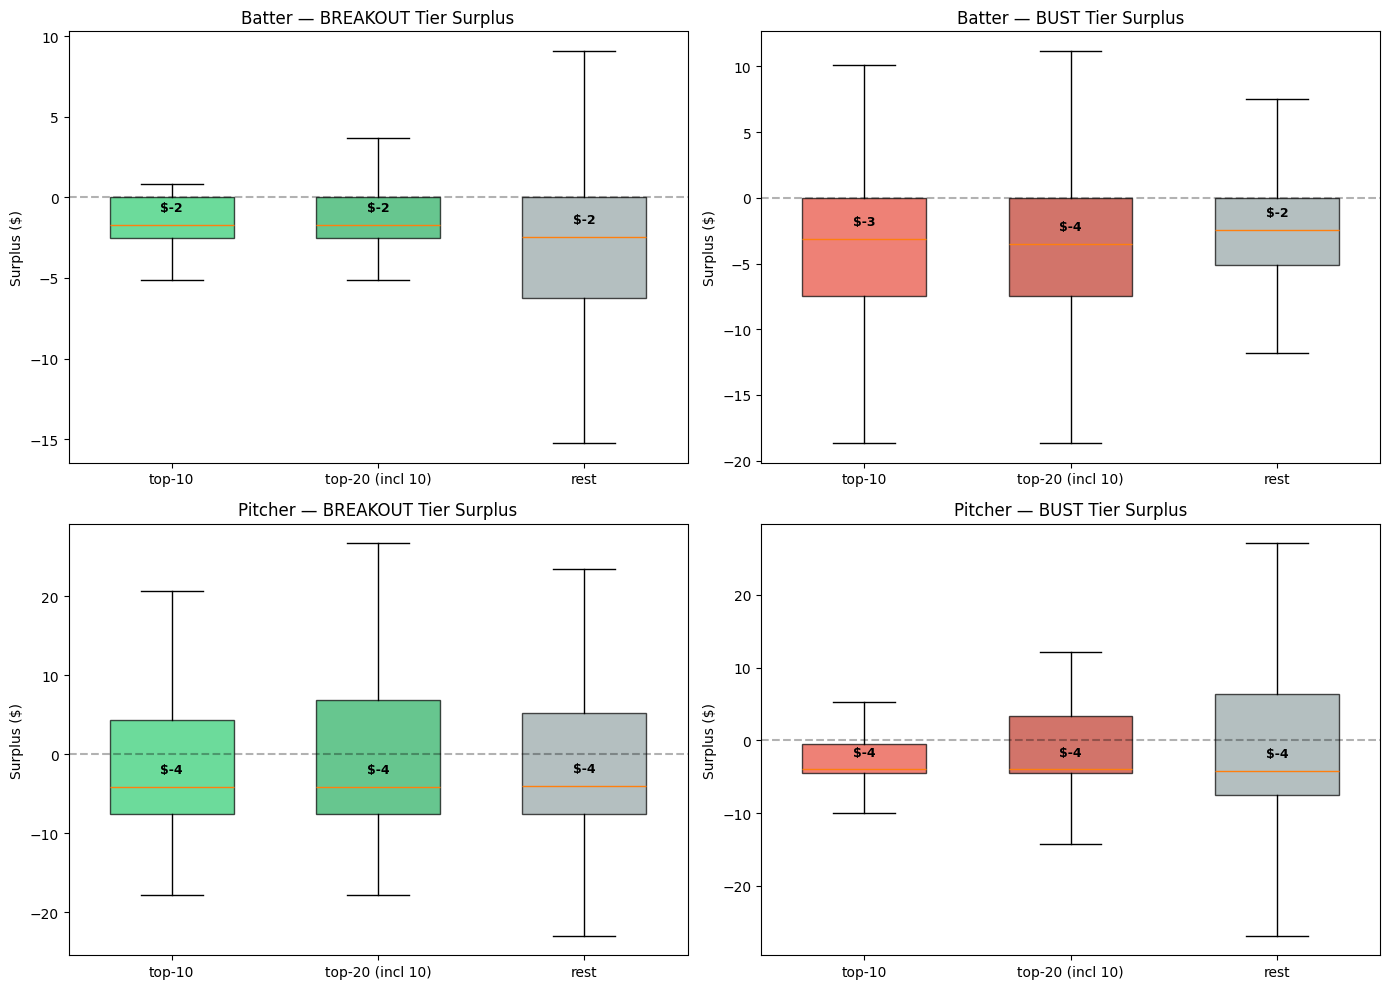

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (signal, signal_df, label) in enumerate(
    [
        ("breakout", breakout_df, "BREAKOUT"),
        ("bust", bust_df, "BUST"),
    ]
):
    for row, ptype in enumerate(("batter", "pitcher")):
        ax = axes[row, col]
        sub = signal_df[signal_df["player_type"] == ptype]
        tier_data = []
        for tier in ["top-10", "top-20", "rest"]:
            t = (
                sub[sub["model_tier"] == tier]
                if tier != "top-20"
                else sub[sub["model_tier"].isin(["top-10", "top-20"])]
            )
            tier_data.append((tier if tier != "top-20" else "top-20 (incl 10)", t["surplus"].values))

        positions = [0, 1, 2]
        bp = ax.boxplot(
            [td[1] for td in tier_data],
            positions=positions,
            widths=0.6,
            patch_artist=True,
            showfliers=False,
        )
        colors = [
            "#2ecc71" if label == "BREAKOUT" else "#e74c3c",
            "#27ae60" if label == "BREAKOUT" else "#c0392b",
            "#95a5a6",
        ]
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels([td[0] for td in tier_data])
        ax.axhline(0, color="black", linestyle="--", alpha=0.3)
        ax.set_ylabel("Surplus ($)")
        ax.set_title(f"{ptype.title()} — {label} Tier Surplus")

        # Annotate medians
        for i, td in enumerate(tier_data):
            median = np.median(td[1])
            ax.annotate(
                f"${median:.0f}",
                (i, median),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=9,
                fontweight="bold",
            )

plt.tight_layout()
plt.show()

## 7. Recommended Adjustments

Compute the final empirical adjustments: the difference in average surplus between model-flagged top-20 and the rest, broken down by player type.

In [9]:
print("=" * 70)
print("  RECOMMENDED VALUATION ADJUSTMENTS")
print("=" * 70)
print()

for signal_name, signal_df in [("BREAKOUT", breakout_df), ("BUST", bust_df)]:
    print(f"  {signal_name} candidates (top-20 by model rank):")
    for ptype in ("batter", "pitcher"):
        sub = signal_df[signal_df["player_type"] == ptype]
        top20 = sub[sub["model_tier"].isin(["top-10", "top-20"])]
        rest = sub[sub["model_tier"] == "rest"]
        edge = top20["surplus"].mean() - rest["surplus"].mean()
        # Also compute median edge for robustness
        median_edge = top20["surplus"].median() - rest["surplus"].median()
        # Compute standard error for confidence
        se = np.sqrt(top20["surplus"].var() / len(top20) + rest["surplus"].var() / len(rest))
        print(
            f"    {ptype:>8s}: mean edge = ${edge:+.1f}  (median = ${median_edge:+.1f}, SE = ${se:.1f}, n_top20 = {len(top20)}, n_rest = {len(rest)})"
        )
    print()

print("  Interpretation:")
print("    - Positive breakout edge = model's top-20 breakout picks deliver")
print("      more surplus than average → bump their valuation UP by that amount")
print("    - Negative bust edge = model's top-20 bust picks deliver less")
print("      surplus than average → discount their valuation DOWN by that amount")
print("    - Use the MEDIAN edge for robustness against outliers")
print("    - SE indicates precision; edges < 2x SE are noisy")
print("=" * 70)

  RECOMMENDED VALUATION ADJUSTMENTS

  BREAKOUT candidates (top-20 by model rank):
      batter: mean edge = $+2.8  (median = $+0.7, SE = $2.7, n_top20 = 80, n_rest = 631)
     pitcher: mean edge = $+0.0  (median = $-0.1, SE = $1.5, n_top20 = 80, n_rest = 335)

  BUST candidates (top-20 by model rank):
      batter: mean edge = $+1.3  (median = $-1.0, SE = $2.0, n_top20 = 80, n_rest = 631)
     pitcher: mean edge = $-0.2  (median = $+0.2, SE = $1.5, n_top20 = 80, n_rest = 335)

  Interpretation:
    - Positive breakout edge = model's top-20 breakout picks deliver
      more surplus than average → bump their valuation UP by that amount
    - Negative bust edge = model's top-20 bust picks deliver less
      surplus than average → discount their valuation DOWN by that amount
    - Use the MEDIAN edge for robustness against outliers
    - SE indicates precision; edges < 2x SE are noisy
